In [4]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, FuncFormatter
from scipy import optimize
from math import pi
from math import sqrt
from numpy import exp
from scipy.optimize import curve_fit
from scipy.interpolate import make_interp_spline
from matplotlib.ticker import MaxNLocator
from scipy.optimize import curve_fit, differential_evolution
from scipy.optimize import minimize_scalar

## Rules implementation

In [2]:
L = 50
frames = 500
interval = 100

def count_neighbors(world):
    return ( np.roll(world,1,0) + np.roll(world,-1,0) + np.roll(world,1,1) + np.roll(world,-1,1) +
             np.roll(np.roll(world,1,0),1,1) + np.roll(np.roll(world,1,0),-1,1) + 
             np.roll(np.roll(world,-1,0),1,1) + np.roll(np.roll(world,-1,0),-1,1) )

def evolve_convolution(world):
    kernel = np.ones((3,3))
    kernel[1,1] = 0
    neighbors = sp.signal.convolve2d(world, kernel, mode = 'same', boundary = 'wrap')
    new_world = np.zeros(world.shape)
    mask = ( (world==1) & ( (neighbors==2) | (neighbors==3) ) ) | ( (world==0) & (neighbors==3) )
    new_world[mask] = 1
    return new_world

def evolve(world):
    neighbors = count_neighbors(world)
    new_world = np.zeros(world.shape)
    mask = ( (world==1) & ( (neighbors==2) | (neighbors==3) ) ) | ( (world==0) & (neighbors==3) )
    new_world[mask] = 1
    return new_world

## Dynamic of the game 
We take a look at the time evolution of several worlds with the same initial density.

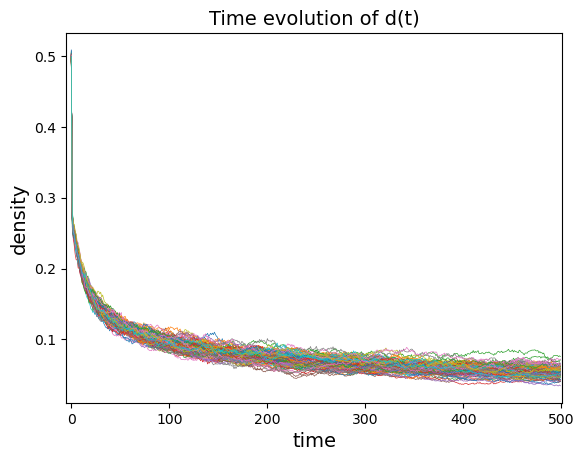

In [3]:
L = 150
T = 500
N = 100 #trajectories generated
time = np.arange(T)
initial_density = 0.5
densities = []
for i in range(N):
    aux_density = []
    world = np.random.random((L,L))
    world[world > initial_density] = 0
    world[world != 0] = 1
    for j in range(T):
        aux_density.append(np.sum(world)/L**2)
        world = evolve(world)
    plt.plot(time,aux_density, lw = 0.5)
    densities.append(aux_density)
plt.xlim(-5, 501) 
plt.xlabel("time", fontsize = 14)
plt.ylabel("density", fontsize = 14)
plt.title("Time evolution of d(t)", fontsize = 14)
plt.show()

Let's see different section of the density troughout the time

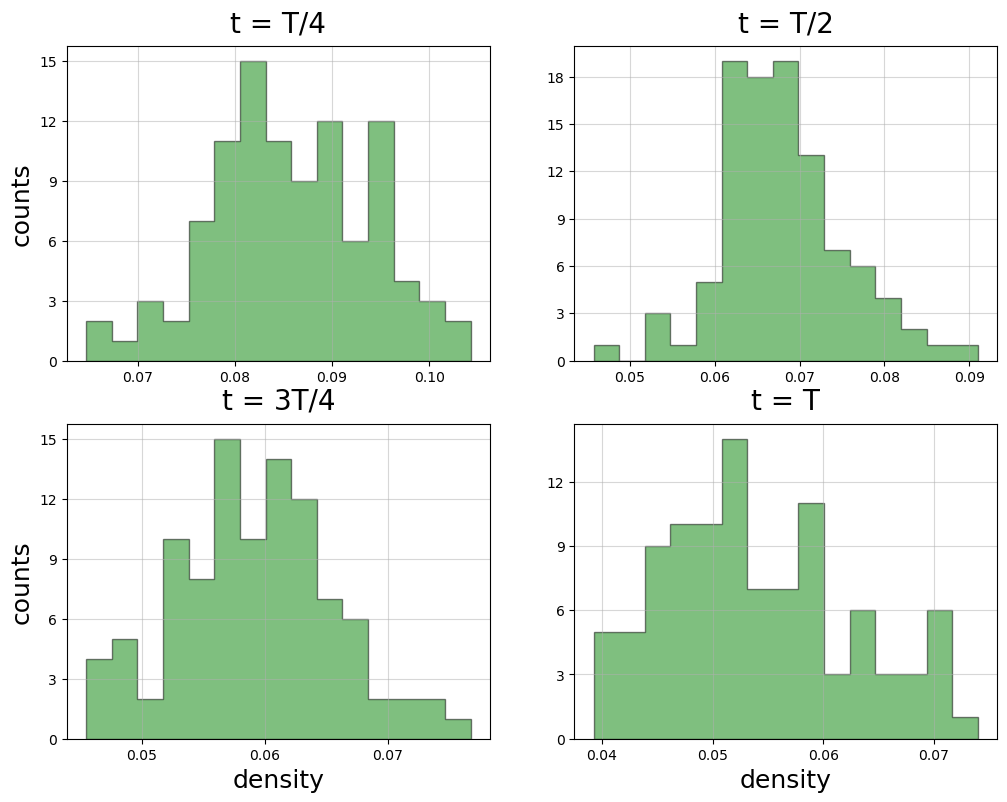

In [8]:
densities = np.array(densities)

fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize=(12, 9))

ax[0][0].hist(densities[:,int(T/4)],15, histtype = 'stepfilled', alpha = 0.5, color = 'green', edgecolor = "black")
ax[0][0].yaxis.set_major_locator(MultipleLocator(3))
ax[0][0].xaxis.set_major_locator(MultipleLocator(0.01))
ax[0][0].set_title("t = T/4", fontsize=20, verticalalignment='bottom')
ax[0][0].grid(alpha=0.5)

ax[0][1].hist(densities[:,int(T/2)],15, histtype = 'stepfilled', alpha = 0.5, color = 'green', edgecolor = "black")
ax[0][1].yaxis.set_major_locator(MultipleLocator(3))
ax[0][1].xaxis.set_major_locator(MultipleLocator(0.01))
ax[0][1].set_title("t = T/2", fontsize=20, verticalalignment='bottom')
ax[0][1].grid(alpha=0.5)

ax[1][0].hist(densities[:,int(3*T/4)],15, histtype = 'stepfilled', alpha = 0.5, color = 'green', edgecolor = "black")
ax[1][0].yaxis.set_major_locator(MultipleLocator(3))
ax[1][0].xaxis.set_major_locator(MultipleLocator(0.01))
ax[1][0].set_title("t = 3T/4", fontsize=20, verticalalignment='bottom')
ax[1][0].grid(alpha=0.5)

ax[1][1].hist(densities[:,T-1],15, histtype = 'stepfilled', alpha = 0.5, color = 'green', edgecolor = "black")
ax[1][1].yaxis.set_major_locator(MultipleLocator(3))
ax[1][1].xaxis.set_major_locator(MultipleLocator(0.01))
ax[1][1].set_title("t = T", fontsize=20, verticalalignment='bottom')
ax[1][1].grid(alpha=0.5)

ax[1][0].set_xlabel("density", fontsize = 18)
ax[1][1].set_xlabel("density", fontsize = 18)
ax[0][0].set_ylabel("counts", fontsize = 18)
ax[1][0].set_ylabel("counts", fontsize = 18)

plt.show()

Since the distribution seems nice, we procede calculating the mean of the differest trajectories at different times

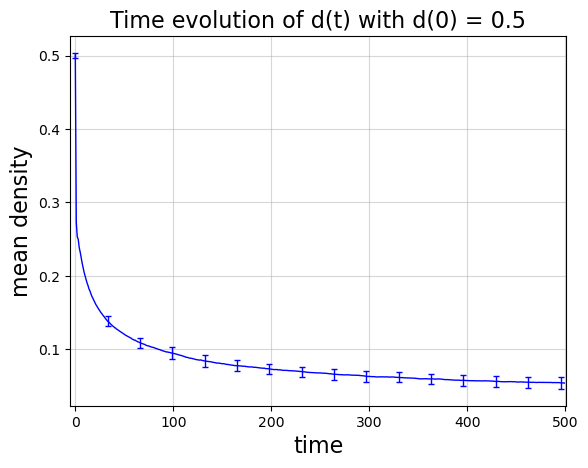

In [9]:
densities = np.array(densities)
mean_density = densities.mean(axis = 0)
std_density = densities.std(axis = 0)
idx = list(range(0,T,int(T/15)))
plt.errorbar(time[idx],mean_density[idx],std_density[idx], ls = '', lw = 1, capsize = 2, color = 'blue')
plt.plot(time,mean_density, ls = '-', lw = 1, color = 'blue')
plt.xlabel("time", fontsize = 16)
plt.ylabel("mean density", fontsize = 16)
plt.title("Time evolution of d(t) with d(0) = 0.5", fontsize = 16)
plt.grid(alpha = 0.5)
plt.xlim(-5, 501) 
plt.show()

## Different sizes of the lattice

In [11]:
T = 1000
N = [80,50,20,15,10,10,10]
L = [30,60,80,120,150,200,250]
d = 0.4

mean_densities = []
mean_std = []
for i in range(len(L)):
    densities = []
    for j in range(N[i]):
        aux_density = []
        world = np.random.random((L[i],L[i]))
        world[world > d] = 0
        world[world != 0] = 1
        for t in range(T):
            aux_density.append(np.sum(world)/L[i]**2)
            world = evolve(world)
        densities.append(aux_density)
    mean_std.append(np.array(densities).std(axis=0))
    mean_densities.append(np.array(densities).mean(axis=0))

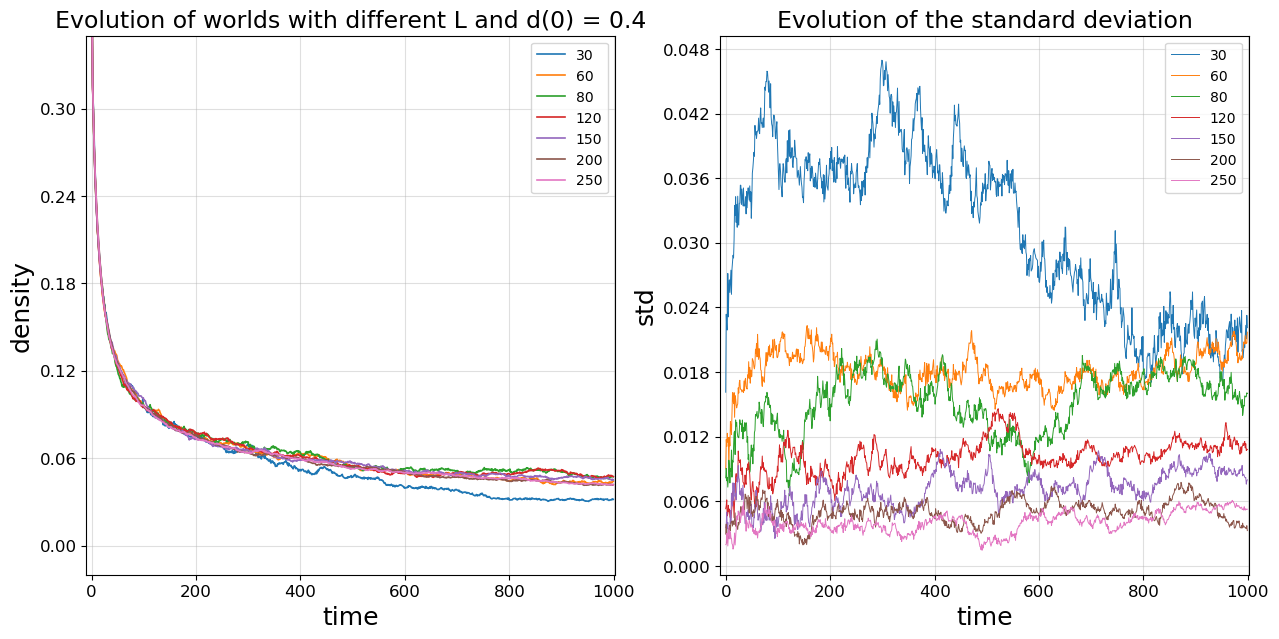

In [12]:
fig, (ax1,ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (15,7))

for i in range(len(mean_densities)):
    ax1.plot(range(T), mean_densities[i], lw = 1.2, label = f"{L[i]}")
    ax2.plot(range(T), mean_std[i], lw = 0.7, label = f"{L[i]}")

ax1.set_xlabel("time", fontsize = 18)
ax1.set_ylabel("density", fontsize = 18)
ax1.set_title("Evolution of worlds with different L and d(0) = 0.4", fontsize = 17)
ax1.set_ylim(-0.02,0.35)
ax2.set_xlabel("time", fontsize = 18)
ax2.set_ylabel("std", fontsize = 18)
ax2.set_title("Evolution of the standard deviation", fontsize = 17)
ax1.legend()
ax2.legend()
ax1.grid(alpha = 0.4)
ax2.grid(alpha = 0.4)
ax1.tick_params(labelsize=12) 
ax1.yaxis.set_major_locator(MaxNLocator(nbins=7))
ax2.tick_params(labelsize=12) 
ax2.yaxis.set_major_locator(MaxNLocator(nbins=9))
ax1.set_xlim(-10, 1002) 
ax2.set_xlim(-10, 1002) 
plt.show()

## Different initial densities:
Now we analyse how the system behaves changing the initial densities. Let's start by chacking how the time evolution goes with different initial densities.

In [13]:
L = 120
T = 2000
N = 50
initial_densities = [0.05, 0.1, 0.15, 0.2, 0.5, 0.6, 0.7, 0.75]

mean_densities = []
mean_std = []
for d in initial_densities:
    densities = []
    for i in range(N):
        aux_density = []
        world = np.random.random((L,L))
        world[world > d] = 0
        world[world != 0] = 1
        for t in range(T):
            aux_density.append(np.sum(world)/L**2)
            world = evolve(world)
        densities.append(aux_density)
    mean_std.append(np.array(densities).std(axis=0))
    mean_densities.append(np.array(densities).mean(axis=0))

In [ ]:
from matplotlib.ticker import MaxNLocator

fig, (ax1,ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (15,7))

for i in range(len(mean_densities)):
    ax1.plot(range(T), mean_densities[i], lw = 1.2, label = f"{initial_densities[i]}")
    ax2.plot(range(T), mean_std[i], lw = 0.7, label = f"{initial_densities[i]}")

ax1.set_xlabel("time", fontsize = 18)
ax1.set_ylabel("density", fontsize = 18)
ax1.set_title("Evolution of worlds with different d(0) and L = 150", fontsize = 17)
ax1.set_ylim(-0.02,0.35)
ax2.set_xlabel("time", fontsize = 18)
ax2.set_ylabel("std", fontsize = 18)
ax2.set_title("Evolution of the standard deviation", fontsize = 17)
ax1.legend()
ax2.legend()
ax1.grid(alpha = 0.4)
ax2.grid(alpha = 0.4)
ax1.tick_params(labelsize=12) 
ax1.yaxis.set_major_locator(MaxNLocator(nbins=7))
ax2.tick_params(labelsize=12) 
ax1.set_xlim(-100, 2002)
ax2.set_xlim(-100, 2002)
ax2.yaxis.set_major_locator(MaxNLocator(nbins=8))
plt.show()

We see that for lowest and higest densities the time evolution seems to be different from the others. Let's study the whole profile of the asymptotyc densities as a function of different initial densities

In [ ]:
#Since the data are saved in the file dati_gol.txt uploaded you can skip the run of this cell
'''
L = 80
T = 9000
DT = 500
N = 20
initial_densities = np.concatenate([np.arange(0,0.1,0.02), np.arange(0.1,0.7,0.1), np.arange(0.7, 0.9, 0.02)])
asymptotic_densities = []
std_densities = []
index = 1
for d in initial_densities:
    aux_density = []
    for i in range(N):
        world = np.random.random((L,L))
        world[world > d] = 0
        world[world != 0] = 1
        for t in range(T):
            world = evolve(world)
        for t in range(T+DT):
            aux_density.append(np.sum(world)/L**2)
            world = evolve(world)
    asymptotic_densities.append(np.array(aux_density).mean())
    std_densities.append(np.array(aux_density).std())
    print(index, " / ", len(initial_densities))
    index += 1


data = np.column_stack([initial_densities, asymptotic_densities, std_densities])
np.savetxt('dati_gol.txt', data, header='x y sigma_y', comments='')
print("Dati salvati in dati_gol.txt")
'''

## Analysis of the asymptotic densities profile

Punti totali: 22, punti usati nel fit: 20


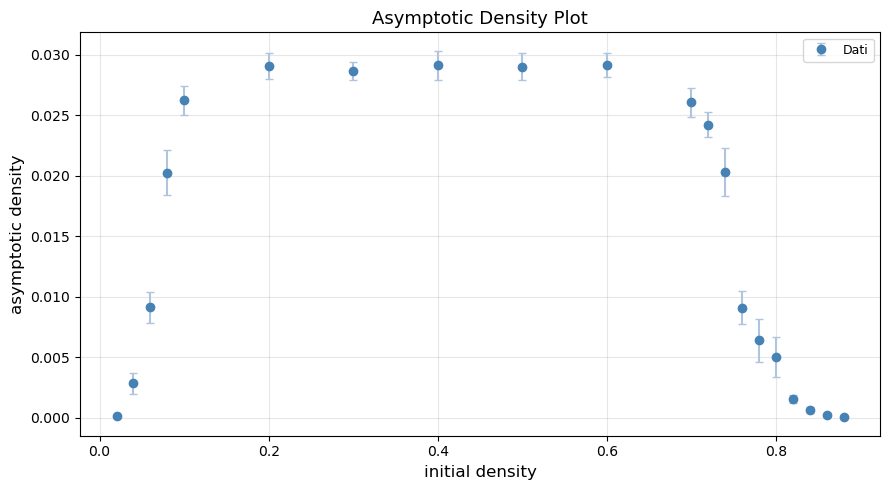

In [2]:
data    = np.loadtxt('dati_gol.txt', skiprows=1)
x       = data[:, 0]
y       = data[:, 1]
sigma_y = data[:, 2]

'''
The mask cuts out the data with y = 0 bc they makes the fit convergence struggle and since they are only
in very lest and very right side they are not even in intresting points to evaluate
''' 
mask_valid  = (y > 0) & (sigma_y > 0)
x           = x[mask_valid]
y           = y[mask_valid]
sigma_y     = sigma_y[mask_valid]/np.sqrt(20)

print(f"Punti totali: {len(data)}, punti usati nel fit: {len(x)}")
fig, ax = plt.subplots(figsize=(9, 5))

ax.errorbar(x, y, yerr=sigma_y, fmt='o', color='steelblue',
            ecolor='lightsteelblue', elinewidth=1.5, capsize=3,
            label='Dati', zorder=3)
ax.set_xlabel('initial density', fontsize=12)
ax.set_ylabel('asymptotic density', fontsize=12)
ax.set_title(f'Asymptotic Density Plot',
             fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# The Richards curve
In this first plot we recognised that the profile was similar to a sigmoid one with two different fronts (left and right).
After a deeper analysis though we saw that our graph presents an asymmetry not very typical of the sigmoid 
(https://en.wikipedia.org/wiki/Sigmoid_function). The model (data driven) that we used as a fit is the Richards Function, 
which is the generalisation of the sigmoid (logistic) function (https://doi.org/10.1093/jxb/10.2.290); in particular this 
function allows us to deal with the asymmetry of our curve.

Let's have a closer look. The Richards Function (R) is:

$$R(x;\, k, x_0, \nu) = \frac{1}{\left(1 + e^{-k(x - x_0)}\right)^{1/\nu}}$$

where, in our case, we can interpret the parameters as:
1. $k$ is the steepness of the sigmoid front: a large $k$ corresponds to a steeprise or fall of the curve,
while a small $k$ gives spread-out transition. The inverse is related to the width of the front
2. $\nu$ is typical of the Richards curve: it controls the asymmetry of the sigmoid front. $\nu\neq 1$ implies that the transition is not symmetric around the inflection point
3. $x_0$ is the point where the function equals $\frac{A}{2^{1/\nu}}$ — a fraction that depends on $\nu$ and coincides with the half-height only in the symmetric case $\nu = 1$. In general it is a purely mathematical position parameter

Since we have two different sigmoids (left and right) we use six parameters and we multiply two different sigmoids for the total fit:

$$f(x) = \frac{A}{\left(1 + e^{-k_1(x - x_1)}\right)^{1/\nu_1} \cdot \left(1 + e^{k_2(x - x_2)}\right)^{1/\nu_2}}$$

where $A$ is a given number representing the $y$ value of the plateau. This one is related to the asymptotic density but we will esteem it later using the plateau data othervise the fit struggle to congerge. For now, we use the value of the asymptotic density that we found in  	
https://doi.org/10.48550/arXiv.1809.03266, that is $A \simeq \rho_{\infty} = 0.02872 \pm 0.00001$

# Fit procedure
In order to perform the fit we will proceed as follows:
1. Using the `scipy` `differential_evolution` function to have an idea of the starting parameters
2. Using the result obtained in point 1. to initialise `curve_fit` from `scipy` to gain precision and to obtain the covariance matrix

The first step is needed because by modifying simultaneously all the parameters one could obtain similar curves. Because of that, the `differential_evolution` method is useful since it works with vectors in the parameter space (6D in the current case), exploring the full parameter space globally. The `curve_fit` algorithm instead uses a gradient-based method (Levenberg-Marquardt) that computes the gradient with respect to all parameters simultaneously, but can be dominated by a single parameter at a time, making it sensitive to the initial guess and could converge to local minima.

In [15]:
#  Valore A dalla letteratura 
A_lit     = 0.02872
A_lit_err = 0.00001

#Modello Richards
def richards(x, k, x0, nu):
    arg     = np.clip(-k * (x - x0), -100, 100)  
    nu_safe = np.maximum(nu, 0.01)                 
    return 1 / (1 + np.exp(arg)) ** (1 / nu_safe)


def model_trap(x, x1, x2, k1, k2, nu1, nu2):
    salita  = richards(x,  k1,  x1,  nu1)
    discesa = richards(-x, k2, -x2,  nu2)
    return A_lit * salita * discesa

#x_n previous evaluation
'''
We evaluate the inflection point using dy. The numpy function convolve is used in order not to relay on one point only
in the evaluation of the dy.
'''
threshold = y.max() * 0.05   # ignora punti sotto il 5% del massimo
mask_sig  = y > threshold

dy = np.gradient(y[mask_sig], x[mask_sig])
dy_smooth = np.convolve(dy, np.ones(3) / 3, mode='same')

x1_guess  = x[mask_sig][np.argmax(dy_smooth)]
x2_guess  = x[mask_sig][np.argmin(dy_smooth)]
print(f"Fronti rilevati: x1 ≈ {x1_guess:.4f},  x2 ≈ {x2_guess:.4f}")

# Bounds for Differential Evolution 
bounds_de = [
    ((x1_guess - 0.02), (x1_guess + 0.02)),                                          # x1
    ((x2_guess - 0.02), (x2_guess + 0.02)),                                          # x2 dentro i dati
    (1.0, 1000.0),                                                                   # k1
    (1.0, 1000.0),                                                                   # k2
    (0.05, 3.0),                                                                     # nu1 — range ristretto per stabilità
    (0.05, 3.0),                                                                     # nu2
]

def chi2(params):
    try:
        return np.sum(((y - model_trap(x, *params)) / sigma_y) ** 2)
    except Exception:
        return 1e10


result_de = differential_evolution(
    chi2, bounds_de,
    seed=42, maxiter=5000, tol=1e-12, #we limit the convergence mechanism near the float precision limit
    polish=True, init='sobol'                                                     
)

print(f"  converged: {result_de.success},  chi2 = {result_de.fun:.4f}")
print(f"  DE params: x1={result_de.x[0]:.4f}, x2={result_de.x[1]:.4f}, "
      f"k1={result_de.x[2]:.1f}, k2={result_de.x[3]:.1f}, "
      f"nu1={result_de.x[4]:.4f}, nu2={result_de.x[5]:.4f}")


# Bounds for curve_fit list comp. same as DE
lower = [b[0] for b in bounds_de] 
upper = [b[1] for b in bounds_de]
bounds_cf = (lower, upper)

#Curve-fit
popt, pcov = curve_fit(
    model_trap, x, y,
    sigma = sigma_y, absolute_sigma = True,
    p0 = result_de.x,
    bounds = bounds_cf,    
    maxfev = 20000
)
errs = np.sqrt(np.diag(pcov))
x1_f, x2_f, k1_f, k2_f, nu1_f, nu2_f = popt

chi2_fit = np.sum(((y - model_trap(x, *popt)) / sigma_y) ** 2)
ndof     = len(x) - len(popt)


print(f"\n  A   = {A_lit:.5f}  ±  {A_lit_err:.5f}   (da letteratura)")
print(f"  x1  = {x1_f:.2f}  ±  {errs[0]:.2f}")
print(f"  x2  = {x2_f:.3f}  ±  {errs[1]:.3f}")
print(f"  k1  = {k1_f:.1f}   ±  {errs[2]:.1f}")
print(f"  k2  = {k2_f:.1f}   ±  {errs[3]:.1f}")
print(f"  nu1 = {nu1_f:.1f}  ±  {errs[4]:.1f}")
print(f"  nu2 = {nu2_f:.1f}  ±  {errs[5]:.1f}")

print(f"\n  chi2 ridotto = {chi2_fit/ndof:.3f}  (ndof = {ndof})")

#A estimation and comparison with a reference (Weighted average of plateau data)
#data 20perc bigger and smaller then x1 and x2
mask_plateau = (x > x1_f + (x2_f - x1_f) * 0.2) & (x < x2_f - (x2_f - x1_f) * 0.2)

if mask_plateau.sum() > 0:
    pesi = 1 / sigma_y[mask_plateau]**2
    A_mio = np.sum(pesi * y[mask_plateau]) / np.sum(pesi)
    A_mio_err = 1 / np.sqrt(np.sum(pesi))
    z = (A_mio - A_lit) / np.sqrt(A_mio_err**2 + A_lit_err**2) #t-test to compare
    print(f"\n  Aw = {A_mio:.4f} ± {A_mio_err:.4f}")
    print(f"  A letteratura = {A_lit:.5f} ± {A_lit_err:.5f}")
    print(f"  Compatibilità: z = {z:.2f} sigma  "
          f"{'OK' if abs(z) < 2 else 'non compatibili'} al 95%\n")

Fronti rilevati: x1 ≈ 0.0600,  x2 ≈ 0.7400


C:\Users\mazzi\AppData\Local\Temp\ipykernel_9144\1413511052.py:9: RuntimeWarning: overflow encountered in power
  return 1 / (1 + np.exp(arg)) ** (1 / nu_safe)


  converged: True,  chi2 = 12.0148
  DE params: x1=0.0489, x2=0.7494, k1=63.1, k2=49.3, nu1=0.3741, nu2=1.1002

  A   = 0.02872  ±  0.00001   (da letteratura)
  x1  = 0.05  ±  0.01
  x2  = 0.749  ±  0.009
  k1  = 63.1   ±  12.3
  k2  = 49.3   ±  8.5
  nu1 = 0.4  ±  0.2
  nu2 = 1.1  ±  0.3

  chi2 ridotto = 0.858  (ndof = 14)

  Aw = 0.0289 ± 0.0004
  A letteratura = 0.02872 ± 0.00001
  Compatibilità: z = 0.49 sigma  OK al 95%



In [9]:
#Evaluation of inflaction points via Monte Carlo
N_samples = 10000 
_pts = np.linspace(x.min(), x.max(), 10000)

samples = np.random.multivariate_normal(popt, pcov, size=N_samples)

flessi_salita  = []
flessi_discesa = []

#we compute the inflection points for every param. set
for sample in samples:
    _y_s  = model_trap(_pts, *sample)
    _dy_s = np.gradient(_y_s, _pts)

    flessi_salita.append(_pts[np.argmax(_dy_s)])
    flessi_discesa.append(_pts[np.argmin(_dy_s)])

flessi_salita  = np.array(flessi_salita)
flessi_discesa = np.array(flessi_discesa)

x1_flesso = np.mean(flessi_salita)
x2_flesso = np.mean(flessi_discesa)

x1_flesso_err = np.std(flessi_salita)
x2_flesso_err = np.std(flessi_discesa)

print(f"Flesso salita:  {x1_flesso:.2f} ± {x1_flesso_err:.2f}")
print(f"Flesso discesa: {x2_flesso:.3f} ± {x2_flesso_err:.3f}")#Calcolo flessi come massimo/minimo della derivata numerica del modello

Flesso salita:  0.07 ± 0.02
Flesso discesa: 0.749 ± 0.005


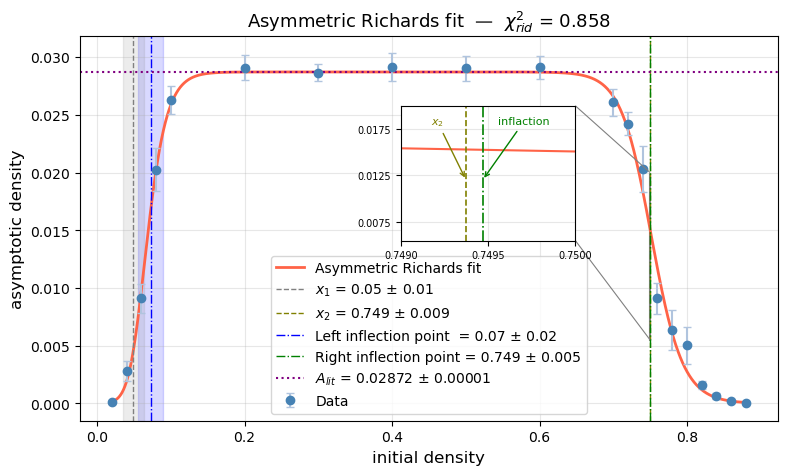

In [11]:
#plot
_y   = model_trap(_pts, *popt)
fig, ax = plt.subplots(figsize=(9, 5))

ax.errorbar(x, y, yerr=sigma_y, fmt='o', color='steelblue',
            ecolor='lightsteelblue', elinewidth=1.5, capsize=3,
            label='Data', zorder=3)
ax.plot(_pts, _y, color='tomato', lw=2, label='Asymmetric Richards fit')
ax.axvline(x1_f,      color='gray',   linestyle='--', lw=1,
           label=f'$x_1$ = {x1_f:.2f} ± {errs[0]:.2f}')
ax.axvline(x2_f,      color='olive',  linestyle='--', lw=1,
           label=f'$x_2$ = {x2_f:.3f} ± {errs[1]:.3f}')
ax.axvline(x1_flesso, color='blue',   linestyle='-.', lw=1,
           label=f'Left inflection point  = {x1_flesso:.2f} ± {x1_flesso_err:.2f}')
ax.axvline(x2_flesso, color='green',  linestyle='-.', lw=1,
           label=f'Right inflection point = {x2_flesso:.3f} ± {x2_flesso_err:.3f}')
ax.axhline(A_lit, color='purple', linestyle=':', lw=1.5,
           label=f'$A_{{lit}}$ = {A_lit:.5f} ± {A_lit_err:.5f}')
ax.axvspan(x1_flesso - x1_flesso_err, x1_flesso + x1_flesso_err,
           alpha=0.15, color='blue')
ax.axvspan(x1_f - errs[0], x1_f + errs[0],
           alpha=0.15, color='gray')
ax.set_xlabel('initial density', fontsize=12)
ax.set_ylabel('asymptotic density', fontsize=12)
ax.set_title(f'Asymmetric Richards fit  —  $\\chi^2_{{rid}}$ = {chi2_fit/ndof:.3f}', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Inset zoom fronte di discesa
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# posizione e dimensione dell'inset
ax_inset = inset_axes(ax, width="25%", height="35%",
                      bbox_to_anchor=(0.45, 0.45, 1, 1),
                      bbox_transform=ax.transAxes,
                      loc='lower left')

ax_inset.errorbar(x, y, yerr=sigma_y, fmt='o', color='steelblue',
                  ecolor='lightsteelblue', elinewidth=1.0, capsize=2, zorder=3)
ax_inset.plot(_pts, _y, color='tomato', lw=1.5)
ax_inset.axvline(x2_f, color='olive', linestyle='--', lw=1.2)
ax_inset.axvline(x2_flesso, color='green', linestyle='-.', lw=1.2)

ax_inset.annotate('$x_2$', xy=(x2_f, 0.012),
                  xytext=(x2_f - 0.0002, 0.018),
                  arrowprops=dict(arrowstyle='->', color='olive'),
                  color='olive', fontsize=8)
ax_inset.annotate('inflaction', xy=(x2_flesso, 0.012),
                  xytext=(x2_flesso + 0.00009, 0.018),
                  arrowprops=dict(arrowstyle='->', color='green'),
                  color='green', fontsize=8)

ax_inset.set_xlim(0.749, 0.75)
ax_inset.set_ylim(0.0055, 0.02)
ax_inset.set_yticks([0.0075, 0.0125, 0.0175])
ax_inset.set_xticks([0.749, 0.7495, 0.75])
ax_inset.tick_params(labelsize=7)
ax_inset.grid(True, alpha=0.3)

mark_inset(ax, ax_inset, loc1=1, loc2=4, fc="none", ec="0.5", lw=0.8)

#plt.tight_layout()
plt.show()

The reduced $\chi^2$ around 1 means that the fit works well

## A ($\rho_{\infty}$) esteem
For the main fit we used A as a fixed parameter to make the fit work better. In the last part of the code in the previous cell in any case we computed a value for A doing the weighted average on the plateau (method that theoretically has the lowest variance). The result is: $A_w = 0.0289 ± 0.0004$ that is compatible with the one from the reference (z = 0.49).
We will after print the graphic rapresentation of this value.

We then do a linear fit with the plateau data mainly to see if m is compatible with 0. Also in that case, just to check the consistency, we find then the centre of the plateau (point that minimise the y variance) and, after evaluating the fit result in that point, we use as A the y value so obtainded. You will see that, without much sorpise, we obtained the same resust (same error as well)

A = 0.0289 ± 0.0004


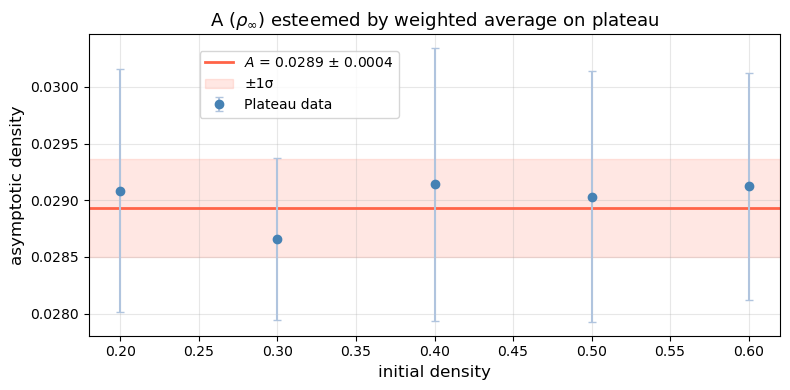

In [13]:
#Weighted average on  plateau
x_plat = x[mask_plateau]
y_plat = y[mask_plateau]
s_plat = sigma_y[mask_plateau]

pesi    = 1 / s_plat**2
A_fixed = np.sum(pesi * y_plat) / np.sum(pesi)
A_fixed_err = 1 / np.sqrt(np.sum(pesi))

print(f"A = {A_fixed:.4f} ± {A_fixed_err:.4f}")

#Plot
fig, ax = plt.subplots(figsize=(8, 4))

ax.errorbar(x_plat, y_plat, yerr=s_plat, fmt='o', color='steelblue',
            ecolor='lightsteelblue', elinewidth=1.5, capsize=3,
            label='Plateau data', zorder=3)

ax.axhline(A_fixed, color='tomato', lw=2,
           label=f'$A$ = {A_fixed:.4f} ± {A_fixed_err:.4f}')
ax.axhspan(A_fixed - A_fixed_err, A_fixed + A_fixed_err,
           alpha=0.15, color='tomato', label='±1σ')

ax.set_xlabel('initial density', fontsize=12)
ax.set_ylabel('asymptotic density', fontsize=12)
ax.set_title(f'A ($\\rho_{{\infty}}$) esteemed by weighted average on plateau', fontsize=13)
ax.legend(fontsize=10, bbox_to_anchor = (0.15,0.7) )
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Fit lineare plateau: q = 0.029 ± 0.001, m = 0.001 ± 0.003
A stimato al centro plateau: 0.0289 ± 0.0004
comp di m con 0: 0.2339377653057339


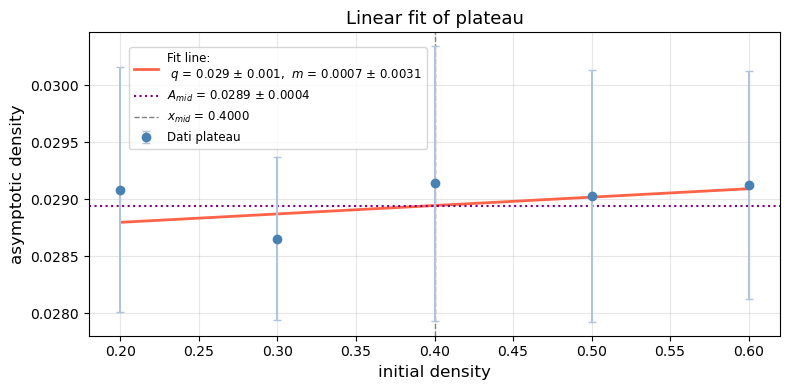

In [14]:
# linear fit
def lineare(x, q, m):
    return q + m * x

popt_lin, pcov_lin = curve_fit(lineare, x_plat, y_plat, sigma=s_plat, absolute_sigma=True)
q_fit, m_fit = popt_lin
q_err, m_err = np.sqrt(np.diag(pcov_lin))

# Center of plateau
x_mid   = (x_plat.min() + x_plat.max()) / 2
A_fixed = lineare(x_mid, q_fit, m_fit)

# error for A = q + m*x_mid
A_fixed_err = np.sqrt(q_err**2 + (x_mid * m_err)**2 + 
                       2 * x_mid * pcov_lin[0,1])  # include covarianza q,m

print(f"Fit lineare plateau: q = {q_fit:.3f} ± {q_err:.3f}, "
      f"m = {m_fit:.3f} ± {m_err:.3f}")
print(f"A stimato al centro plateau: {A_fixed:.4f} ± {A_fixed_err:.4f}")
print(f'comp di m con 0: {m_fit/m_err}')

#plot
fig, ax = plt.subplots(figsize=(8, 4))

ax.errorbar(x_plat, y_plat, yerr=s_plat, fmt='o', color='steelblue',
            ecolor='lightsteelblue', elinewidth=1.5, capsize=3,
            label='Dati plateau', zorder=3)

_pts = np.linspace(x_plat.min(), x_plat.max(), 300)
ax.plot(_pts, lineare(_pts, q_fit, m_fit), color='tomato', lw=2,
        label=f'Fit line: \n $q$ = {q_fit:.3f} ± {q_err:.3f},  $m$ = {m_fit:.4f} ± {m_err:.4f}')

ax.axhline(A_fixed, color='purple', linestyle=':', lw=1.5,
           label=f'$A_{{mid}}$ = {A_fixed:.4f} ± {A_fixed_err:.4f}')
ax.axvline(x_mid, color='gray', linestyle='--', lw=1,
           label=f'$x_{{mid}}$ = {x_mid:.4f}')

ax.set_xlabel('initial density', fontsize=12)
ax.set_ylabel('asymptotic density', fontsize=12)
ax.set_title('Linear fit of plateau', fontsize=13)
ax.legend(fontsize=8.5, loc='upper left', bbox_to_anchor=(0.05, 0.97))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()